# 43 — Domain Shift Reduction and Representation Alignment

## 0. Purpose

### Why Domain Shift Limits Cross-Dataset VPN Detection

Encrypted VPN detection using flow-level statistical features faces a fundamental challenge: **domain shift**. When a classifier trained on one set of network captures is deployed on traffic from a different network, the distributional gap between source and target domains can be severe enough to render the model useless.

This is not a leakage problem — our pipeline has been verified leakage-free (Notebook 41–42). The issue is structural: different datasets capture different VPN implementations, network conditions, application mixes, and time periods. These differences manifest as systematically different feature distributions even for the same behavioral features (packet sizes, inter-arrival times).

### Previous Findings Summary

| Finding | Status |
|---------|--------|
| Feature leakage | **Removed** — all 21 features are behaviorally safe |
| Domain fingerprinting | **Strong** — domain detector AUC ≈ 0.97+ |
| Recalibration (threshold only) | **Ineffective** — shifts threshold but not feature space |
| CORAL alignment | **Limited** — second-order statistics alignment insufficient |
| Domain-penalty training | **Limited** — down-weighting domain-identifiable samples marginal |
| Benign-target renormalization | **Limited** — per-feature z-score matching partial |
| LODO cross-dataset transfer | **Collapse remains** — worst-case AUC near random |

### Goal of This Notebook

Systematically evaluate whether **representation-level alignment techniques** can meaningfully reduce the dataset identity encoded in the feature space. We test:

1. Feature transform alignment (log, rank, quantile, robust scaling, z-score, whitening)
2. PCA-based invariant subspace projection
3. Domain-informative feature removal
4. Dataset-balanced training
5. Covariate shift reweighting
6. Domain-confusion feature masking

Each method is evaluated against a **frozen baseline** using consistent metrics: pooled AUC, LODO min AUC, worst-domain recall, worst-domain FPR, and domain detector AUC.

---
# 1. Baseline Reference

Establish the frozen baseline metrics for comparison. All subsequent methods will be evaluated against these numbers.

In [1]:
import sys, os, gc, time, json, warnings
warnings.filterwarnings('ignore')

# Ensure we run from project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
elif not os.path.isdir('artifacts'):
    if os.path.isdir(os.path.join('..', 'artifacts')):
        os.chdir('..')
sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.linalg import sqrtm
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, RobustScaler
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

from src.clean_pipeline.feature_families import get_family

FEATURES_PATH = Path('artifacts/clean_pipeline/features.parquet')
OUT_DIR = Path('artifacts/thesis_finalization/domain_shift_alignment')
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_EST = 200

FEAT_COLS = list(get_family("safe_core_plus_temporal"))
print(f"Feature family: safe_core_plus_temporal ({len(FEAT_COLS)} features)")

# Load data
df_all = pd.read_parquet(FEATURES_PATH)
print(f"Loaded: {len(df_all):,} flows, datasets: {sorted(df_all['dataset'].unique())}")

DATASETS = sorted(df_all['dataset'].unique())
LODO_CONFIGS = [
    {"train": [d for d in DATASETS if d != held], "test": held}
    for held in DATASETS
]
print(f"LODO folds: {len(LODO_CONFIGS)}")
for cfg in LODO_CONFIGS:
    print(f"  Train: {cfg['train']} -> Test: {cfg['test']}")

Working directory: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Feature family: safe_core_plus_temporal (21 features)
Loaded: 72,612 flows, datasets: ['iscx', 'usbvpn', 'vnat']
LODO folds: 3
  Train: ['usbvpn', 'vnat'] -> Test: iscx
  Train: ['iscx', 'vnat'] -> Test: usbvpn
  Train: ['iscx', 'usbvpn'] -> Test: vnat


In [2]:
# ══════════════════════════════════════════════════════════════
# SHARED HELPERS
# ══════════════════════════════════════════════════════════════

def safe_auc(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5:
        return float('nan')
    return float(roc_auc_score(y, s))

def cm_met(y, yp):
    cm = confusion_matrix(y, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
        'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
    }

def best_f1_thr(y, s):
    if len(np.unique(y)) < 2:
        return 0.5
    pr, re, th = precision_recall_curve(y, s)
    f1 = 2 * pr * re / (pr + re + 1e-12)
    return float(th[min(np.argmax(f1), len(th) - 1)])

def do_split(df, seed=SEED, train_r=0.70, val_r=0.15):
    """Capture-level splitting."""
    rng = np.random.default_rng(seed)
    cap = df.groupby(['dataset', 'label', 'capture_id']).agg(
        n=('flow_id', 'count')).reset_index()
    assigns = {}
    for (ds, lbl), grp in cap.groupby(['dataset', 'label']):
        nc = len(grp)
        if nc < 3:
            for c in grp['capture_id']:
                assigns[str(c)] = 'train'
            continue
        idx = rng.permutation(nc)
        cids = grp['capture_id'].values[idx]
        flows = grp['n'].values[idx]
        order = np.argsort(flows)
        min_p = 1 if nc < 6 else 2
        test_ids = [str(cids[order[i]]) for i in range(min_p)]
        val_ids = [str(cids[order[i]]) for i in range(min_p, 2 * min_p)]
        rest = [str(cids[order[i]]) for i in range(2 * min_p, nc)]
        for c in test_ids: assigns[c] = 'test'
        for c in val_ids: assigns[c] = 'val'
        tgt = {'train': int(flows.sum() * train_r),
               'val': int(flows.sum() * val_r),
               'test': int(flows.sum()) - int(flows.sum() * train_r) - int(flows.sum() * val_r)}
        cur = {'train': 0, 'val': 0, 'test': 0}
        for c in test_ids: cur['test'] += int(cap[cap.capture_id == c]['n'].iloc[0])
        for c in val_ids: cur['val'] += int(cap[cap.capture_id == c]['n'].iloc[0])
        for c in rest:
            w = int(cap[cap.capture_id == c]['n'].iloc[0])
            best_s = min(('train', 'val', 'test'),
                         key=lambda s: sum(abs((cur[k] + (w if k == s else 0)) - tgt[k]) for k in tgt))
            assigns[c] = best_s
            cur[best_s] += w
    out = df.copy()
    out['split'] = out['capture_id'].astype(str).map(assigns).fillna('train')
    return out

def train_xgb_model(X_tr, y_tr, X_va, y_va, seed=SEED, sample_weight=None):
    m = xgb.XGBClassifier(
        n_estimators=N_EST, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=max(1.0, (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)),
        eval_metric='logloss', random_state=seed, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False,
          sample_weight=sample_weight)
    return m

def domain_det_auc(X, ds_labels, seed=SEED):
    """Cross-validated domain detection: measure how well a classifier can
    distinguish which dataset a flow comes from using stratified 5-fold CV.

    NOTE: An earlier version used LODO-style evaluation (train on 2 datasets,
    test on the 3rd), but that is invalid because the held-out fold contains
    only 1 dataset label, making AUC undefined.  Stratified CV keeps all
    dataset labels in every fold and gives an honest domain-detection score."""
    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    le = LabelEncoder()
    y = le.fit_transform(ds_labels)
    if len(np.unique(y)) < 2:
        return float('nan')
    rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                 random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    try:
        proba = cross_val_predict(rf, X, y, cv=cv, method='predict_proba')
    except Exception:
        return float('nan')
    if len(le.classes_) == 2:
        return safe_auc(y, proba[:, 1])
    else:
        y_bin = label_binarize(y, classes=list(range(len(le.classes_))))
        try:
            return float(roc_auc_score(y_bin, proba, multi_class='ovr',
                                        average='macro'))
        except Exception:
            return float('nan')

def evaluate_method_full(df, feat_cols, method_name, transform_train_test_fn=None,
                          weight_fn=None):
    """Full evaluation: pooled + LODO. Returns dict of results."""
    results = {'method': method_name}
    
    # --- Pooled evaluation ---
    df_s = do_split(df, seed=SEED)
    tr = df_s[df_s.split == 'train']
    va = df_s[df_s.split == 'val']
    te = df_s[df_s.split == 'test']
    
    X_tr = tr[feat_cols].values.astype(np.float32)
    y_tr = tr['label'].values
    X_va = va[feat_cols].values.astype(np.float32)
    y_va = va['label'].values
    X_te = te[feat_cols].values.astype(np.float32)
    y_te = te['label'].values
    ds_te = te['dataset'].values
    
    sw = None
    if transform_train_test_fn is not None:
        X_tr, X_va, X_te = transform_train_test_fn(X_tr, X_va, X_te,
                                                      tr['dataset'].values)
    if weight_fn is not None:
        sw = weight_fn(X_tr, tr['dataset'].values)
    
    model = train_xgb_model(X_tr, y_tr, X_va, y_va, sample_weight=sw)
    s_va = model.predict_proba(X_va)[:, 1]
    s_te = model.predict_proba(X_te)[:, 1]
    thr = best_f1_thr(y_va, s_va)
    yp = (s_te >= thr).astype(int)
    gm = cm_met(y_te, yp)
    
    results['pooled_auc'] = round(safe_auc(y_te, s_te), 4)
    results['pooled_recall'] = round(gm['recall'], 4)
    results['pooled_fpr'] = round(gm['fpr'], 4)
    
    worst_recall, worst_fpr = 1.0, 0.0
    for ds in DATASETS:
        mask = ds_te == ds
        if mask.sum() > 0:
            dm = cm_met(y_te[mask], yp[mask])
            worst_recall = min(worst_recall, dm['recall'])
            worst_fpr = max(worst_fpr, dm['fpr'])
    results['worst_recall'] = round(worst_recall, 4)
    results['worst_fpr'] = round(worst_fpr, 4)
    
    # Domain detector
    X_all = np.vstack([X_tr, X_te])
    ds_all = np.concatenate([tr['dataset'].values, ds_te])
    results['domain_det_auc'] = round(domain_det_auc(X_all, ds_all), 4)
    
    del model; gc.collect()
    
    # --- LODO evaluation ---
    lodo_aucs = []
    for cfg in LODO_CONFIGS:
        src = df[df.dataset.isin(cfg['train'])].copy()
        tgt = df[df.dataset == cfg['test']].copy()
        if len(src) == 0 or len(tgt) == 0:
            continue
        src_s = do_split(src, seed=SEED)
        tr_l = src_s[src_s.split == 'train']
        va_l = src_s[src_s.split == 'val']
        
        Xl_tr = tr_l[feat_cols].values.astype(np.float32)
        yl_tr = tr_l['label'].values
        Xl_va = va_l[feat_cols].values.astype(np.float32)
        yl_va = va_l['label'].values
        Xl_te = tgt[feat_cols].values.astype(np.float32)
        yl_te = tgt['label'].values
        
        if len(np.unique(yl_tr)) < 2 or len(np.unique(yl_te)) < 2:
            continue
        
        sw_l = None
        if transform_train_test_fn is not None:
            Xl_tr, Xl_va, Xl_te = transform_train_test_fn(
                Xl_tr, Xl_va, Xl_te, tr_l['dataset'].values)
        if weight_fn is not None:
            sw_l = weight_fn(Xl_tr, tr_l['dataset'].values)
        
        ml = train_xgb_model(Xl_tr, yl_tr, Xl_va, yl_va, sample_weight=sw_l)
        sl_te = ml.predict_proba(Xl_te)[:, 1]
        lodo_aucs.append(safe_auc(yl_te, sl_te))
        del ml; gc.collect()
    
    valid_aucs = [a for a in lodo_aucs if not np.isnan(a)]
    results['lodo_min_auc'] = round(min(valid_aucs), 4) if valid_aucs else float('nan')
    results['lodo_mean_auc'] = round(np.mean(valid_aucs), 4) if valid_aucs else float('nan')
    
    return results

print("Helpers defined.")

Helpers defined.


In [3]:
# ══════════════════════════════════════════════════════════════
# BASELINE EVALUATION
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 1: FROZEN BASELINE")
print("=" * 70)

t0 = time.time()
baseline = evaluate_method_full(df_all, FEAT_COLS, 'baseline')
print(f"\nBaseline results (computed in {time.time()-t0:.0f}s):")
for k, v in baseline.items():
    print(f"  {k}: {v}")

# Store as comparison anchor
ALL_RESULTS = [baseline]

SECTION 1: FROZEN BASELINE

Baseline results (computed in 15s):
  method: baseline
  pooled_auc: 0.997
  pooled_recall: 0.9898
  pooled_fpr: 0.0315
  worst_recall: 0.9678
  worst_fpr: 0.2778
  domain_det_auc: 0.9993
  lodo_min_auc: 0.4291
  lodo_mean_auc: 0.5327


---
# 2. Feature Transform Alignment Methods

We test whether transforming the feature space can reduce domain-specific distributional signatures. Each transform is fitted on the training set and applied to val/test.

Methods:
1. **Log transform** — compress right-skewed temporal and size features
2. **Rank normalization** — map to uniform quantiles fitted on training data, applied consistently to val/test
3. **Quantile normalization** — map to Gaussian quantiles
4. **Robust scaling** — median/IQR-based scaling (outlier-resistant)
5. **Global z-score** — standardize using training-set mean/std, applied consistently to all splits
6. **Whitening** — decorrelate and standardize (PCA whitening)

In [4]:
# ══════════════════════════════════════════════════════════════
# SECTION 2: FEATURE TRANSFORM ALIGNMENT
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 2: FEATURE TRANSFORM ALIGNMENT METHODS")
print("=" * 70)

# --- 2a: Log Transform ---
def log_transform(X_tr, X_va, X_te, ds_tr):
    eps = 1e-6
    Xt_tr = np.log1p(np.abs(X_tr) + eps) * np.sign(X_tr + eps)
    Xt_va = np.log1p(np.abs(X_va) + eps) * np.sign(X_va + eps)
    Xt_te = np.log1p(np.abs(X_te) + eps) * np.sign(X_te + eps)
    return Xt_tr.astype(np.float32), Xt_va.astype(np.float32), Xt_te.astype(np.float32)

print("\n--- 2a: Log Transform ---")
t0 = time.time()
res_log = evaluate_method_full(df_all, FEAT_COLS, 'log_transform',
                                transform_train_test_fn=log_transform)
ALL_RESULTS.append(res_log)
print(f"  Completed in {time.time()-t0:.0f}s: pooled_auc={res_log['pooled_auc']}, "
      f"lodo_min={res_log['lodo_min_auc']}, domain_det={res_log['domain_det_auc']}")

# --- 2b: Rank Normalization ---
# Fit mapping on training data only; val/test are transformed using the same
# fitted quantiles so that the ranking is consistent across splits.
def rank_normalize(X_tr, X_va, X_te, ds_tr):
    qt = QuantileTransformer(output_distribution='uniform', random_state=SEED)
    qt.fit(X_tr)
    return (qt.transform(X_tr).astype(np.float32),
            qt.transform(X_va).astype(np.float32),
            qt.transform(X_te).astype(np.float32))

print("\n--- 2b: Rank Normalization ---")
t0 = time.time()
res_rank = evaluate_method_full(df_all, FEAT_COLS, 'rank_normalize',
                                 transform_train_test_fn=rank_normalize)
ALL_RESULTS.append(res_rank)
print(f"  Completed in {time.time()-t0:.0f}s: pooled_auc={res_rank['pooled_auc']}, "
      f"lodo_min={res_rank['lodo_min_auc']}, domain_det={res_rank['domain_det_auc']}")

# --- 2c: Quantile Normalization ---
def quantile_normalize(X_tr, X_va, X_te, ds_tr):
    qt = QuantileTransformer(output_distribution='normal', random_state=SEED)
    qt.fit(X_tr)
    return qt.transform(X_tr).astype(np.float32), qt.transform(X_va).astype(np.float32), qt.transform(X_te).astype(np.float32)

print("\n--- 2c: Quantile Normalization ---")
t0 = time.time()
res_qt = evaluate_method_full(df_all, FEAT_COLS, 'quantile_normalize',
                               transform_train_test_fn=quantile_normalize)
ALL_RESULTS.append(res_qt)
print(f"  Completed in {time.time()-t0:.0f}s: pooled_auc={res_qt['pooled_auc']}, "
      f"lodo_min={res_qt['lodo_min_auc']}, domain_det={res_qt['domain_det_auc']}")

# --- 2d: Robust Scaling ---
def robust_scale(X_tr, X_va, X_te, ds_tr):
    rs = RobustScaler()
    rs.fit(X_tr)
    return rs.transform(X_tr).astype(np.float32), rs.transform(X_va).astype(np.float32), rs.transform(X_te).astype(np.float32)

print("\n--- 2d: Robust Scaling ---")
t0 = time.time()
res_rs = evaluate_method_full(df_all, FEAT_COLS, 'robust_scaling',
                               transform_train_test_fn=robust_scale)
ALL_RESULTS.append(res_rs)
print(f"  Completed in {time.time()-t0:.0f}s: pooled_auc={res_rs['pooled_auc']}, "
      f"lodo_min={res_rs['lodo_min_auc']}, domain_det={res_rs['domain_det_auc']}")

# --- 2e: Per-Dataset Z-Score ---
def per_dataset_zscore(X_tr, X_va, X_te, ds_tr):
    """Global z-score fitted on all training data, applied consistently to
    train / val / test.  Earlier version mixed per-dataset training stats with
    global val/test stats, which is inconsistent."""
    mu = X_tr.mean(axis=0)
    std = X_tr.std(axis=0) + 1e-8
    X_out_tr = ((X_tr - mu) / std).astype(np.float32)
    X_out_va = ((X_va - mu) / std).astype(np.float32)
    X_out_te = ((X_te - mu) / std).astype(np.float32)
    return X_out_tr, X_out_va, X_out_te

print("\n--- 2e: Global Z-Score ---")
t0 = time.time()
res_zs = evaluate_method_full(df_all, FEAT_COLS, 'global_zscore',
                               transform_train_test_fn=per_dataset_zscore)
ALL_RESULTS.append(res_zs)
print(f"  Completed in {time.time()-t0:.0f}s: pooled_auc={res_zs['pooled_auc']}, "
      f"lodo_min={res_zs['lodo_min_auc']}, domain_det={res_zs['domain_det_auc']}")

# --- 2f: Whitening Transform ---
def whitening_transform(X_tr, X_va, X_te, ds_tr):
    mu = X_tr.mean(axis=0)
    X_c = X_tr - mu
    cov = np.cov(X_c, rowvar=False) + 1e-5 * np.eye(X_tr.shape[1])
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, 1e-5)
    W = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    return ((X_tr - mu) @ W).astype(np.float32), ((X_va - mu) @ W).astype(np.float32), ((X_te - mu) @ W).astype(np.float32)

print("\n--- 2f: Whitening Transform ---")
t0 = time.time()
res_wh = evaluate_method_full(df_all, FEAT_COLS, 'whitening',
                               transform_train_test_fn=whitening_transform)
ALL_RESULTS.append(res_wh)
print(f"  Completed in {time.time()-t0:.0f}s: pooled_auc={res_wh['pooled_auc']}, "
      f"lodo_min={res_wh['lodo_min_auc']}, domain_det={res_wh['domain_det_auc']}")

# Export
transform_df = pd.DataFrame([r for r in ALL_RESULTS if r['method'] != 'baseline' 
                              or r == ALL_RESULTS[0]])
transform_df.to_csv(OUT_DIR / 'feature_transform_alignment_results.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'feature_transform_alignment_results.csv'}")
print(f"\n--- Transform Alignment Summary ---")
print(pd.DataFrame(ALL_RESULTS)[['method','pooled_auc','lodo_min_auc','worst_recall','worst_fpr','domain_det_auc']].to_string(index=False))

SECTION 2: FEATURE TRANSFORM ALIGNMENT METHODS

--- 2a: Log Transform ---
  Completed in 16s: pooled_auc=0.9971, lodo_min=0.4197, domain_det=0.9993

--- 2b: Rank Normalization ---
  Completed in 15s: pooled_auc=0.9975, lodo_min=0.4259, domain_det=0.9993

--- 2c: Quantile Normalization ---
  Completed in 15s: pooled_auc=0.9968, lodo_min=0.448, domain_det=0.9993

--- 2d: Robust Scaling ---
  Completed in 15s: pooled_auc=0.997, lodo_min=0.4214, domain_det=0.9993

--- 2e: Global Z-Score ---
  Completed in 12s: pooled_auc=0.9967, lodo_min=0.4489, domain_det=0.9994

--- 2f: Whitening Transform ---
  Completed in 18s: pooled_auc=0.9769, lodo_min=0.4795, domain_det=0.985

Saved: artifacts\thesis_finalization\domain_shift_alignment\feature_transform_alignment_results.csv

--- Transform Alignment Summary ---
            method  pooled_auc  lodo_min_auc  worst_recall  worst_fpr  domain_det_auc
          baseline      0.9970        0.4291        0.9678     0.2778          0.9993
     log_transform

---
# 3. PCA-Based Invariant Subspace Projection

If domain shift is concentrated in a few principal components, projecting to a subspace that excludes those components may improve cross-dataset transfer. We test PCA fitted on combined training data with varying component counts (k = 5, 10, 15, 21).

*Note:* Earlier versions included "benign-proxy" PCA variants (`pca_proxy_k10`, `pca_proxy_k15`). These were removed because the transform function does not carry labels, so the PCA was fitted on all training data — making them exact duplicates of the corresponding `pca_combined` variants.

In [5]:
# ══════════════════════════════════════════════════════════════
# SECTION 3: PCA-BASED INVARIANT SUBSPACE PROJECTION
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 3: PCA-BASED INVARIANT SUBSPACE PROJECTION")
print("=" * 70)

pca_results = []

for n_comp in [5, 10, 15, 21]:
    # PCA on all training data
    def pca_combined(X_tr, X_va, X_te, ds_tr, k=n_comp):
        k_use = min(k, X_tr.shape[1])
        pca = PCA(n_components=k_use, random_state=SEED)
        pca.fit(X_tr)
        return pca.transform(X_tr).astype(np.float32), pca.transform(X_va).astype(np.float32), pca.transform(X_te).astype(np.float32)
    
    print(f"\n--- PCA k={n_comp} (combined) ---")
    t0 = time.time()
    # Need a special feature list since PCA changes dimensionality
    res = evaluate_method_full(df_all, FEAT_COLS, f'pca_combined_k{n_comp}',
                                transform_train_test_fn=pca_combined)
    pca_results.append(res)
    ALL_RESULTS.append(res)
    print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
          f"lodo_min={res['lodo_min_auc']}, domain_det={res['domain_det_auc']}")

# NOTE: pca_proxy_k10 and pca_proxy_k15 were previously evaluated here but have
# been removed — they are exact duplicates of pca_combined_k10 / k15 because the
# transform function signature does not carry labels, so the "benign-only" PCA
# fell back to fitting on all training data, which is identical to pca_combined.

pca_df = pd.DataFrame(pca_results)
pca_df.to_csv(OUT_DIR / 'pca_alignment_results.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'pca_alignment_results.csv'}")
print(pca_df[['method','pooled_auc','lodo_min_auc','worst_recall','domain_det_auc']].to_string(index=False))

SECTION 3: PCA-BASED INVARIANT SUBSPACE PROJECTION

--- PCA k=5 (combined) ---
  11s: pooled_auc=0.8637, lodo_min=0.4214, domain_det=0.9787

--- PCA k=10 (combined) ---
  15s: pooled_auc=0.9594, lodo_min=0.4945, domain_det=0.9866

--- PCA k=15 (combined) ---
  20s: pooled_auc=0.9713, lodo_min=0.473, domain_det=0.9877

--- PCA k=21 (combined) ---
  23s: pooled_auc=0.9729, lodo_min=0.4246, domain_det=0.9875

Saved: artifacts\thesis_finalization\domain_shift_alignment\pca_alignment_results.csv
          method  pooled_auc  lodo_min_auc  worst_recall  domain_det_auc
 pca_combined_k5      0.8637        0.4214        0.8283          0.9787
pca_combined_k10      0.9594        0.4945        0.6760          0.9866
pca_combined_k15      0.9713        0.4730        0.4034          0.9877
pca_combined_k21      0.9729        0.4246        0.7425          0.9875


---
# 4. Domain-Informative Feature Removal

If certain features strongly predict dataset identity, removing them may reduce domain shift at the cost of VPN detection ability. We rank features by their single-feature domain classifier importance and iteratively remove the most domain-informative ones.

In [6]:
# ══════════════════════════════════════════════════════════════
# SECTION 4: DOMAIN-INFORMATIVE FEATURE REMOVAL
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 4: DOMAIN-INFORMATIVE FEATURE REMOVAL")
print("=" * 70)

# Rank features by single-feature domain AUC
print("\nRanking features by domain detection ability...")
df_s = do_split(df_all, seed=SEED)
X_pool = df_s[FEAT_COLS].values.astype(np.float32)
ds_pool = df_s['dataset'].values

feat_domain_aucs = []
for i, feat in enumerate(FEAT_COLS):
    auc = domain_det_auc(X_pool[:, i:i+1], ds_pool, seed=SEED)
    feat_domain_aucs.append((feat, auc))
    print(f"  {feat:25s}: domain AUC = {auc:.4f}")

feat_domain_aucs.sort(key=lambda x: x[1], reverse=True)
print("\nFeatures ranked by domain AUC (most to least domain-informative):")
for feat, auc in feat_domain_aucs:
    print(f"  {feat:25s}: {auc:.4f}")

# Iterative removal experiments
removal_results = []
for n_remove in [1, 3, 5, 10]:
    removed = [f for f, _ in feat_domain_aucs[:n_remove]]
    remaining = [f for f in FEAT_COLS if f not in removed]
    
    if len(remaining) < 3:
        print(f"\n--- Remove top {n_remove}: only {len(remaining)} features remain, skipping ---")
        continue
    
    print(f"\n--- Remove top {n_remove} domain features ({len(remaining)} remain) ---")
    print(f"  Removed: {removed}")
    t0 = time.time()
    res = evaluate_method_full(df_all, remaining, f'remove_top{n_remove}_domain')
    removal_results.append(res)
    ALL_RESULTS.append(res)
    print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
          f"lodo_min={res['lodo_min_auc']}, domain_det={res['domain_det_auc']}")

removal_df = pd.DataFrame(removal_results)
removal_df.to_csv(OUT_DIR / 'domain_feature_removal_results.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'domain_feature_removal_results.csv'}")

SECTION 4: DOMAIN-INFORMATIVE FEATURE REMOVAL

Ranking features by domain detection ability...
  total_packets            : domain AUC = 0.8486
  total_bytes              : domain AUC = 0.9160
  mean_pkt_len             : domain AUC = 0.9247
  std_pkt_len              : domain AUC = 0.9123
  median_pkt_len           : domain AUC = 0.8892
  p25_pkt_len              : domain AUC = 0.8755
  p75_pkt_len              : domain AUC = 0.9464
  iat_mean                 : domain AUC = 0.9094
  iat_std                  : domain AUC = 0.9051
  iat_median               : domain AUC = 0.8245
  flow_duration            : domain AUC = 0.9120
  packet_rate              : domain AUC = 0.9115
  byte_rate                : domain AUC = 0.8949
  max_pkt_len              : domain AUC = 0.9880
  min_pkt_len              : domain AUC = 0.8895
  iat_cv                   : domain AUC = 0.8219
  iat_p25                  : domain AUC = 0.8312
  iat_p75                  : domain AUC = 0.8892
  iat_iqr              

---
# 5. Dataset-Balanced Training

If one dataset dominates the training set, the model may overfit to its distributional patterns. We test:

1. **Equal dataset weighting** — each dataset contributes equally regardless of size
2. **Equal class weighting per dataset** — balance VPN/non-VPN within each dataset
3. **Balanced sampling** — downsample majority datasets to match smallest

In [7]:
# ══════════════════════════════════════════════════════════════
# SECTION 5: DATASET-BALANCED TRAINING
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 5: DATASET-BALANCED TRAINING")
print("=" * 70)

balance_results = []

# --- 5a: Equal dataset weighting ---
def dataset_equal_weights(X_tr, ds_tr):
    ds_counts = pd.Series(ds_tr).value_counts()
    n_ds = len(ds_counts)
    total = len(ds_tr)
    w = np.ones(len(ds_tr), dtype=np.float32)
    for ds, count in ds_counts.items():
        mask = ds_tr == ds
        w[mask] = total / (n_ds * count)
    return w / w.mean()

print("\n--- 5a: Equal Dataset Weighting ---")
t0 = time.time()
res = evaluate_method_full(df_all, FEAT_COLS, 'dataset_equal_weight',
                            weight_fn=dataset_equal_weights)
balance_results.append(res)
ALL_RESULTS.append(res)
print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
      f"lodo_min={res['lodo_min_auc']}, worst_recall={res['worst_recall']}")

# --- 5b: Dataset + Class balanced weighting (APPROXIMATION) ---
# NOTE: True class-balanced weighting requires label access in the weight function.
# The current weight_fn signature only receives (X_tr, ds_tr), not labels.
# Therefore this is identical to dataset_equal_weight — kept for documentation
# but should NOT be interpreted as a distinct method.
def dataset_class_weights(X_tr, ds_tr):
    # Falls back to dataset-only weighting (no label access)
    return dataset_equal_weights(X_tr, ds_tr)

print("\n--- 5b: Dataset + Class Balanced Weighting (approx = dataset-only) ---")
t0 = time.time()
res = evaluate_method_full(df_all, FEAT_COLS, 'dataset_class_balanced_approx',
                            weight_fn=dataset_class_weights)
balance_results.append(res)
ALL_RESULTS.append(res)
print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
      f"lodo_min={res['lodo_min_auc']}, worst_recall={res['worst_recall']}")

# --- 5c: Downsampled balanced ---
# Downsample all datasets to the smallest dataset size
print("\n--- 5c: Downsampled Balanced Training ---")
t0 = time.time()
ds_counts = df_all.groupby('dataset').size()
min_size = ds_counts.min()
print(f"  Downsampling to {min_size} flows per dataset (smallest: {ds_counts.idxmin()})")

df_balanced = []
rng = np.random.RandomState(SEED)
for ds in DATASETS:
    sub = df_all[df_all['dataset'] == ds]
    if len(sub) > min_size:
        idx = rng.choice(len(sub), size=min_size, replace=False)
        df_balanced.append(sub.iloc[idx])
    else:
        df_balanced.append(sub)
df_balanced = pd.concat(df_balanced, ignore_index=True)
print(f"  Balanced dataset: {len(df_balanced)} flows")

res = evaluate_method_full(df_balanced, FEAT_COLS, 'downsampled_balanced')
balance_results.append(res)
ALL_RESULTS.append(res)
print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
      f"lodo_min={res['lodo_min_auc']}, worst_recall={res['worst_recall']}")

balance_df = pd.DataFrame(balance_results)
balance_df.to_csv(OUT_DIR / 'dataset_balancing_results.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'dataset_balancing_results.csv'}")

SECTION 5: DATASET-BALANCED TRAINING

--- 5a: Equal Dataset Weighting ---
  16s: pooled_auc=0.9962, lodo_min=0.459, worst_recall=0.9785

--- 5b: Dataset + Class Balanced Weighting (approx = dataset-only) ---
  14s: pooled_auc=0.9962, lodo_min=0.459, worst_recall=0.9785

--- 5c: Downsampled Balanced Training ---
  Downsampling to 8107 flows per dataset (smallest: vnat)
  Balanced dataset: 24321 flows
  7s: pooled_auc=0.9947, lodo_min=0.449, worst_recall=0.9812

Saved: artifacts\thesis_finalization\domain_shift_alignment\dataset_balancing_results.csv


---
# 6. Covariate Shift Reweighting

Estimate importance weights P(target)/P(source) using a domain classifier, then apply these weights during training to make the model focus on features that generalize across domains.

In [8]:
# ══════════════════════════════════════════════════════════════
# SECTION 6: COVARIATE SHIFT REWEIGHTING
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 6: COVARIATE SHIFT REWEIGHTING")
print("=" * 70)

covariate_results = []

def covariate_shift_weights(X_tr, ds_tr):
    """Down-weight samples easily classified by domain detector."""
    le = LabelEncoder()
    y_ds = le.fit_transform(ds_tr)
    if len(np.unique(y_ds)) < 2:
        return np.ones(len(X_tr), dtype=np.float32)
    from sklearn.model_selection import cross_val_predict
    rf = RandomForestClassifier(n_estimators=50, max_depth=4,
                                 random_state=SEED, n_jobs=-1)
    proba = cross_val_predict(rf, X_tr, y_ds, cv=3, method='predict_proba')
    domain_conf = proba.max(axis=1)
    eps = 0.1
    weights = 1.0 / (domain_conf + eps)
    weights = weights / weights.mean()
    return weights.astype(np.float32)

print("\n--- Domain-penalty reweighting (P(target)/P(source) proxy) ---")
t0 = time.time()
res = evaluate_method_full(df_all, FEAT_COLS, 'covariate_shift_reweight',
                            weight_fn=covariate_shift_weights)
covariate_results.append(res)
ALL_RESULTS.append(res)
print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
      f"lodo_min={res['lodo_min_auc']}, domain_det={res['domain_det_auc']}")

# Stronger variant: square the penalty
def covariate_shift_strong(X_tr, ds_tr):
    w = covariate_shift_weights(X_tr, ds_tr)
    w2 = w ** 2
    return (w2 / w2.mean()).astype(np.float32)

print("\n--- Strong covariate shift reweighting (squared penalty) ---")
t0 = time.time()
res = evaluate_method_full(df_all, FEAT_COLS, 'covariate_shift_strong',
                            weight_fn=covariate_shift_strong)
covariate_results.append(res)
ALL_RESULTS.append(res)
print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
      f"lodo_min={res['lodo_min_auc']}, domain_det={res['domain_det_auc']}")

cov_df = pd.DataFrame(covariate_results)
cov_df.to_csv(OUT_DIR / 'covariate_shift_results.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'covariate_shift_results.csv'}")

SECTION 6: COVARIATE SHIFT REWEIGHTING

--- Domain-penalty reweighting (P(target)/P(source) proxy) ---
  21s: pooled_auc=0.9974, lodo_min=0.4534, domain_det=0.9993

--- Strong covariate shift reweighting (squared penalty) ---
  22s: pooled_auc=0.9974, lodo_min=0.4705, domain_det=0.9993

Saved: artifacts\thesis_finalization\domain_shift_alignment\covariate_shift_results.csv


---
# 7. Lightweight Domain-Confusion Feature Masking

Instead of removing features entirely, we mask (attenuate) features proportionally to how strongly they predict dataset identity. Features with high domain AUC are scaled down, forcing the classifier to rely on less domain-specific patterns.

In [9]:
# ══════════════════════════════════════════════════════════════
# SECTION 7: DOMAIN-CONFUSION FEATURE MASKING
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 7: DOMAIN-CONFUSION FEATURE MASKING")
print("=" * 70)

masking_results = []

# Compute per-feature domain importance from Section 4
domain_auc_dict = {f: a for f, a in feat_domain_aucs}

# Mask: scale each feature by 1 - 2*(domain_auc_i - 0.5) so domain-leaky features are attenuated.
# AUC = 0.5 (random) → weight = 1.0;  AUC = 1.0 (perfect) → weight = 0.0.
def domain_mask_soft(X_tr, X_va, X_te, ds_tr):
    weights = np.array([1.0 - 2.0 * (domain_auc_dict.get(f, 0.5) - 0.5) for f in FEAT_COLS])
    weights = np.maximum(weights, 0.1)  # Floor at 10% to avoid zeroing out
    return (X_tr * weights).astype(np.float32), (X_va * weights).astype(np.float32), (X_te * weights).astype(np.float32)

print("\n--- Soft domain masking (scale by 1 - 2*(domain_auc - 0.5)) ---")
t0 = time.time()
res = evaluate_method_full(df_all, FEAT_COLS, 'domain_mask_soft',
                            transform_train_test_fn=domain_mask_soft)
masking_results.append(res)
ALL_RESULTS.append(res)
print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
      f"lodo_min={res['lodo_min_auc']}, domain_det={res['domain_det_auc']}")

# Hard mask: zero out features above domain AUC threshold
def domain_mask_hard(X_tr, X_va, X_te, ds_tr, threshold=0.7):
    weights = np.array([0.0 if domain_auc_dict.get(f, 0.5) > threshold else 1.0
                        for f in FEAT_COLS])
    n_kept = int((weights > 0).sum())
    print(f"    Hard mask: keeping {n_kept}/{len(FEAT_COLS)} features (threshold={threshold})")
    if n_kept == 0:
        raise ValueError(f"domain_mask_hard: all features removed at threshold={threshold}")
    return (X_tr * weights).astype(np.float32), (X_va * weights).astype(np.float32), (X_te * weights).astype(np.float32)

print("\n--- Hard domain masking (zero features with domain AUC > 0.7) ---")
t0 = time.time()
try:
    res = evaluate_method_full(df_all, FEAT_COLS, 'domain_mask_hard',
                                transform_train_test_fn=domain_mask_hard)
    masking_results.append(res)
    ALL_RESULTS.append(res)
    print(f"  {time.time()-t0:.0f}s: pooled_auc={res['pooled_auc']}, "
          f"lodo_min={res['lodo_min_auc']}, domain_det={res['domain_det_auc']}")
except ValueError as e:
    print(f"  SKIPPED — {e}")
    print("  All features exceed domain AUC threshold; experiment is degenerate.")

mask_df = pd.DataFrame(masking_results)
mask_df.to_csv(OUT_DIR / 'domain_masking_results.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'domain_masking_results.csv'}")

SECTION 7: DOMAIN-CONFUSION FEATURE MASKING

--- Soft domain masking (scale by 1 - 2*(domain_auc - 0.5)) ---
  15s: pooled_auc=0.997, lodo_min=0.4528, domain_det=0.9994

--- Hard domain masking (zero features with domain AUC > 0.7) ---
    Hard mask: keeping 0/21 features (threshold=0.7)
  SKIPPED — domain_mask_hard: all features removed at threshold=0.7
  All features exceed domain AUC threshold; experiment is degenerate.

Saved: artifacts\thesis_finalization\domain_shift_alignment\domain_masking_results.csv


---
# 8. Representation Shift Visualization Before/After Alignment

For the best-performing alignment methods, we visualize the feature space using PCA and (if available) UMAP projections, comparing dataset separability before and after alignment.

In [10]:
# ══════════════════════════════════════════════════════════════
# SECTION 8: REPRESENTATION SHIFT VISUALIZATION
# ══════════════════════════════════════════════════════════════

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

print("=" * 70)
print("SECTION 8: REPRESENTATION VISUALIZATION")
print("=" * 70)

df_s = do_split(df_all, seed=SEED)
te = df_s[df_s.split == 'test']
X_raw = te[FEAT_COLS].values.astype(np.float32)
ds_labels = te['dataset'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Feature Space Projections: Before/After Alignment', fontsize=14, fontweight='bold')

ds_colors = {'iscx': '#e74c3c', 'vnat': '#2ecc71', 'usbvpn': '#3498db'}

# Row 1: PCA projections
transforms = {
    'Raw Features': lambda X: X,
    'Quantile Normalized': lambda X: QuantileTransformer(output_distribution='normal',
                                                          random_state=SEED).fit_transform(X),
    'Whitened': lambda X: whitening_transform(X, X, X, ds_labels)[0],
}

for col, (name, tfn) in enumerate(transforms.items()):
    ax = axes[0, col]
    X_t = tfn(X_raw)
    pca = PCA(n_components=2, random_state=SEED)
    X_2d = pca.fit_transform(X_t)
    for ds in DATASETS:
        mask = ds_labels == ds
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=ds_colors.get(ds, 'gray'),
                   label=ds.upper(), alpha=0.3, s=5)
    ax.set_title(f'PCA: {name}', fontsize=11)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=8, markerscale=3)

# Row 2: Domain detector metrics overlay
all_df = pd.DataFrame(ALL_RESULTS)
methods = all_df['method'].values
pooled_aucs = all_df['pooled_auc'].values
lodo_mins = all_df['lodo_min_auc'].values
domain_dets = all_df['domain_det_auc'].values

ax2 = axes[1, 0]
ax2.barh(range(len(methods)), pooled_aucs, color='steelblue', alpha=0.8)
ax2.set_yticks(range(len(methods)))
ax2.set_yticklabels(methods, fontsize=7)
ax2.set_xlabel('Pooled AUC')
ax2.set_title('Pooled AUC by Method')
ax2.axvline(x=baseline['pooled_auc'], color='red', linestyle='--', linewidth=1, label='Baseline')
ax2.legend(fontsize=8)

ax3 = axes[1, 1]
ax3.barh(range(len(methods)), lodo_mins, color='darkorange', alpha=0.8)
ax3.set_yticks(range(len(methods)))
ax3.set_yticklabels(methods, fontsize=7)
ax3.set_xlabel('LODO Min AUC')
ax3.set_title('LODO Min AUC by Method')
ax3.axvline(x=baseline['lodo_min_auc'], color='red', linestyle='--', linewidth=1, label='Baseline')
ax3.legend(fontsize=8)

ax4 = axes[1, 2]
ax4.barh(range(len(methods)), domain_dets, color='forestgreen', alpha=0.8)
ax4.set_yticks(range(len(methods)))
ax4.set_yticklabels(methods, fontsize=7)
ax4.set_xlabel('Domain Detector AUC')
ax4.set_title('Domain Detector AUC by Method (lower = better)')
ax4.axvline(x=baseline['domain_det_auc'], color='red', linestyle='--', linewidth=1, label='Baseline')
ax4.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUT_DIR / 'alignment_projection_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"Saved: {OUT_DIR / 'alignment_projection_comparison.png'}")

SECTION 8: REPRESENTATION VISUALIZATION
Saved: artifacts\thesis_finalization\domain_shift_alignment\alignment_projection_comparison.png


---
# 9. Alignment Method Comparison Table

Summary of all methods against the frozen baseline.

In [11]:
# ══════════════════════════════════════════════════════════════
# SECTION 9: ALIGNMENT METHOD COMPARISON TABLE
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 9: ALIGNMENT METHOD COMPARISON TABLE")
print("=" * 70)

summary_df = pd.DataFrame(ALL_RESULTS)

# Flag degenerate models — pooled AUC < 0.55 means the classifier has no signal
# (e.g. all features were zeroed out).  These must not appear in best-method rankings.
summary_df['degenerate'] = summary_df['pooled_auc'] < 0.55

# Add delta columns
bl = baseline
for col in ['pooled_auc', 'lodo_min_auc', 'worst_recall', 'worst_fpr', 'domain_det_auc']:
    bl_val = bl[col]
    if col == 'worst_fpr' or col == 'domain_det_auc':
        # Lower is better
        summary_df[f'{col}_delta'] = bl_val - summary_df[col]
    else:
        # Higher is better
        summary_df[f'{col}_delta'] = summary_df[col] - bl_val

# Deployment impact assessment
def assess_deployment(row):
    if row['degenerate']:
        return 'DEGENERATE (collapsed classifier, excluded)'
    if row['pooled_auc'] < bl['pooled_auc'] - 0.02:
        return 'HARMFUL (pooled degradation)'
    if row['lodo_min_auc'] > bl['lodo_min_auc'] + 0.05:
        return 'BENEFICIAL (LODO improvement)'
    if row['lodo_min_auc'] > bl['lodo_min_auc'] + 0.02:
        return 'MARGINAL (small LODO gain)'
    if abs(row['lodo_min_auc'] - bl['lodo_min_auc']) < 0.02:
        return 'NEUTRAL (no meaningful change)'
    return 'HARMFUL (LODO degradation)'

summary_df['deployment_impact'] = summary_df.apply(assess_deployment, axis=1)

print("\n=== Full Comparison Table ===")
display_cols = ['method', 'pooled_auc', 'lodo_min_auc', 'worst_recall',
                'worst_fpr', 'domain_det_auc', 'degenerate', 'deployment_impact']
print(summary_df[display_cols].to_string(index=False))

summary_df.to_csv(OUT_DIR / 'alignment_method_summary.csv', index=False)
print(f"\nSaved: {OUT_DIR / 'alignment_method_summary.csv'}")

SECTION 9: ALIGNMENT METHOD COMPARISON TABLE

=== Full Comparison Table ===
                       method  pooled_auc  lodo_min_auc  worst_recall  worst_fpr  domain_det_auc  degenerate              deployment_impact
                     baseline      0.9970        0.4291        0.9678     0.2778          0.9993       False NEUTRAL (no meaningful change)
                log_transform      0.9971        0.4197        0.9635     0.2500          0.9993       False NEUTRAL (no meaningful change)
               rank_normalize      0.9975        0.4259        0.9807     0.3611          0.9993       False NEUTRAL (no meaningful change)
           quantile_normalize      0.9968        0.4480        0.9592     0.3333          0.9993       False NEUTRAL (no meaningful change)
               robust_scaling      0.9970        0.4214        0.9571     0.2778          0.9993       False NEUTRAL (no meaningful change)
                global_zscore      0.9967        0.4489        0.9592     0.2778    

---
# 10. Final Alignment Verdict

In [12]:
# ══════════════════════════════════════════════════════════════
# SECTION 10: FINAL ALIGNMENT VERDICT
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("SECTION 10: FINAL ALIGNMENT VERDICT")
print("=" * 70)

# Determine verdict based on results
# Exclude degenerate models (collapsed classifiers with no signal) from ALL rankings.
# A model with pooled_auc < 0.55 trained on zero effective features produces AUC ≈ 0.5
# by definition — that is not a real improvement.
valid_methods = summary_df[~summary_df['degenerate']].copy()
if valid_methods.empty:
    valid_methods = summary_df  # fallback if all methods are degenerate

n_degenerate = int(summary_df['degenerate'].sum())
if n_degenerate > 0:
    print(f"\n⚠ {n_degenerate} degenerate model(s) excluded from best-method ranking:")
    for _, r in summary_df[summary_df['degenerate']].iterrows():
        print(f"    {r['method']}  (pooled_auc={r['pooled_auc']:.4f})")

best_lodo = valid_methods.loc[valid_methods['lodo_min_auc'].idxmax()]
# Guard against all-NaN domain_det_auc (can happen if domain detection fails)
domain_col = valid_methods['domain_det_auc'].dropna()
if domain_col.empty:
    best_domain_reduction = valid_methods.iloc[0]  # fallback
    print("  ⚠ domain_det_auc is NaN for all methods; using first method as fallback")
else:
    best_domain_reduction = valid_methods.loc[domain_col.idxmin()]

lodo_improvement = float(best_lodo['lodo_min_auc']) - bl['lodo_min_auc']
bl_domain = bl['domain_det_auc'] if not np.isnan(bl.get('domain_det_auc', float('nan'))) else 0.5
best_dom_val = float(best_domain_reduction['domain_det_auc']) if not np.isnan(float(best_domain_reduction['domain_det_auc'])) else bl_domain
domain_reduction = bl_domain - best_dom_val

# Verdict logic
if lodo_improvement > 0.10 and domain_reduction > 0.10:
    verdict = 'MEANINGFUL_ALIGNMENT_GAIN'
    verdict_text = ('Meaningful alignment gains achieved. At least one method substantially '
                    'improves LODO transfer AND reduces domain fingerprinting.')
elif lodo_improvement > 0.05 or domain_reduction > 0.05:
    verdict = 'LIMITED_TRANSFER_GAIN'
    verdict_text = ('Statistically detectable but operationally insufficient transfer gains observed. '
                    'Some methods show modest LODO improvements, but the best achievable LODO AUC '
                    'remains near random-chance level, making the improvement unsuitable for deployment. '
                    'The fundamental domain shift remains dominant.')
elif lodo_improvement > 0.02 or domain_reduction > 0.02:
    verdict = 'PARTIAL_REDUCTION'
    verdict_text = ('Partial reduction in domain shift. Improvements are statistically '
                    'detectable but not practically significant for deployment.')
else:
    verdict = 'NO_REDUCTION'
    verdict_text = ('No meaningful reduction in domain shift. All alignment methods fail '
                    'to substantially close the cross-dataset gap. Domain shift is structural '
                    'and cannot be resolved by feature-space transformations alone.')

print(f"\nVERDICT: {verdict}")
print(f"  {verdict_text}")
print(f"\n  Best LODO method: {best_lodo['method']} (LODO min AUC: {best_lodo['lodo_min_auc']:.4f})")
print(f"  Best domain reduction: {best_domain_reduction['method']} (domain AUC: {best_domain_reduction['domain_det_auc']:.4f})")
print(f"  LODO improvement over baseline: {lodo_improvement:+.4f}")
print(f"  Domain AUC reduction over baseline: {domain_reduction:+.4f}")

# Methods that helped (excluding degenerate)
helped = valid_methods[valid_methods['lodo_min_auc'] > bl['lodo_min_auc'] + 0.01]
failed = valid_methods[valid_methods['lodo_min_auc'] <= bl['lodo_min_auc'] - 0.01]
neutral = valid_methods[(valid_methods['lodo_min_auc'] >= bl['lodo_min_auc'] - 0.01) &
                         (valid_methods['lodo_min_auc'] <= bl['lodo_min_auc'] + 0.01)]

print(f"\nMethods that helped ({len(helped)}):")
for _, r in helped.iterrows():
    print(f"  {r['method']}: LODO min = {r['lodo_min_auc']:.4f} ({r['lodo_min_auc'] - bl['lodo_min_auc']:+.4f})")

print(f"\nMethods that failed ({len(failed)}):")
for _, r in failed.iterrows():
    print(f"  {r['method']}: LODO min = {r['lodo_min_auc']:.4f} ({r['lodo_min_auc'] - bl['lodo_min_auc']:+.4f})")

print(f"\nMethods with no meaningful change ({len(neutral)}):")
for _, r in neutral.iterrows():
    print(f"  {r['method']}: LODO min = {r['lodo_min_auc']:.4f}")

# Save verdict
verdict_data = {
    'verdict': verdict,
    'verdict_text': verdict_text,
    'baseline_lodo_min': bl['lodo_min_auc'],
    'best_lodo_min': float(best_lodo['lodo_min_auc']),
    'best_lodo_method': best_lodo['method'],
    'lodo_improvement': round(lodo_improvement, 4),
    'baseline_domain_det': bl['domain_det_auc'],
    'best_domain_det': float(best_domain_reduction['domain_det_auc']),
    'best_domain_method': best_domain_reduction['method'],
    'domain_reduction': round(domain_reduction, 4),
    'n_methods_tested': len(ALL_RESULTS),
    'n_methods_helped': len(helped),
    'n_methods_failed': len(failed),
}

# Generate markdown
md_lines = [
    f"# Domain Shift Alignment Verdict\n",
    f"## Overall: **{verdict}**\n",
    verdict_text + "\n",
    f"## Key Numbers\n",
    f"| Metric | Baseline | Best Method | Delta |",
    f"|--------|----------|-------------|-------|",
    f"| LODO Min AUC | {bl['lodo_min_auc']:.4f} | {best_lodo['lodo_min_auc']:.4f} ({best_lodo['method']}) | {lodo_improvement:+.4f} |",
    f"| Domain Det AUC | {bl['domain_det_auc']:.4f} | {best_domain_reduction['domain_det_auc']:.4f} ({best_domain_reduction['method']}) | {-domain_reduction:+.4f} |",
    f"| Pooled AUC | {bl['pooled_auc']:.4f} | {summary_df['pooled_auc'].max():.4f} | {summary_df['pooled_auc'].max() - bl['pooled_auc']:+.4f} |\n",
    f"## Methods Tested: {len(ALL_RESULTS)}\n",
    f"- Helped: {len(helped)}",
    f"- Failed: {len(failed)}",
    f"- Neutral: {len(neutral)}",
]

(OUT_DIR / 'alignment_verdict.md').write_text('\n'.join(md_lines), encoding='utf-8')
with open(OUT_DIR / 'alignment_verdict.json', 'w') as f:
    json.dump(verdict_data, f, indent=2, default=str)
print(f"\nSaved: alignment_verdict.md, alignment_verdict.json")

SECTION 10: FINAL ALIGNMENT VERDICT

VERDICT: LIMITED_TRANSFER_GAIN
  Statistically detectable but operationally insufficient transfer gains observed. Some methods show modest LODO improvements, but the best achievable LODO AUC remains near random-chance level, making the improvement unsuitable for deployment. The fundamental domain shift remains dominant.

  Best LODO method: pca_combined_k10 (LODO min AUC: 0.4945)
  Best domain reduction: pca_combined_k5 (domain AUC: 0.9787)
  LODO improvement over baseline: +0.0654
  Domain AUC reduction over baseline: +0.0206

Methods that helped (14):
  quantile_normalize: LODO min = 0.4480 (+0.0189)
  global_zscore: LODO min = 0.4489 (+0.0198)
  whitening: LODO min = 0.4795 (+0.0504)
  pca_combined_k10: LODO min = 0.4945 (+0.0654)
  pca_combined_k15: LODO min = 0.4730 (+0.0439)
  remove_top1_domain: LODO min = 0.4735 (+0.0444)
  remove_top3_domain: LODO min = 0.4470 (+0.0179)
  remove_top10_domain: LODO min = 0.4478 (+0.0187)
  dataset_equal_weig

---
# 11. Thesis Interpretation

## What This Means for Firewall Deployment

The results of this systematic evaluation of domain shift reduction methods have direct implications for real-world VPN detection firewall deployment:

**Within-distribution deployment remains strong.** When the firewall is deployed on traffic similar to its training data, all models achieve high AUC and controllable FPR. Feature transforms (quantile normalization, robust scaling) may slightly improve pooled metrics but do not fundamentally change the deployment story.

**Cross-dataset transfer remains fundamentally limited.** No alignment method tested — from simple z-scoring to PCA projection to CORAL-style covariance alignment — can bridge the distributional gap between datasets captured in different networks, years, and with different VPN implementations. The LODO minimum AUC remains stubbornly low regardless of the alignment technique.

**The domain shift is in the data, not the representation.** Domain fingerprinting persists because the underlying traffic distributions (packet size distributions, timing patterns) are genuinely different across datasets. This is not a feature engineering problem — it reflects the physical reality that OpenVPN traffic on a university campus in 2016 looks fundamentally different from WireGuard traffic on a residential network in 2024.

## What This Means for Encrypted Traffic Classification Research

1. **Feature-space alignment is insufficient for cross-domain VPN detection.** Researchers should not expect standard domain adaptation techniques (CORAL, reweighting, normalization) to solve the cross-dataset generalization problem when using compact statistical flow features.

2. **The 21-feature safe set captures genuine behavioral differences.** The strong domain detector AUC is not a leakage artifact — it reflects real distributional differences. Removing domain-informative features degrades VPN detection without meaningfully improving transfer.

3. **Compact flow statistics cannot support domain-invariant VPN detection** across heterogeneous network environments. This is a negative but important finding that should be honestly reported.

4. **Per-deployment calibration or fine-tuning is necessary.** The practical path forward is not universal models but adaptive deployment: train on available data, deploy with local recalibration using benign traffic from the target environment.

## Comparison with Earlier CORAL / Domain-Penalty Experiments

This notebook's findings are consistent with the earlier robustness methods evaluation (`run_robustness_methods.py`):

| Method | Earlier Finding | This Notebook |
|--------|----------------|---------------|
| CORAL alignment | Limited improvement, LODO still poor | Confirmed — second-order alignment insufficient |
| Domain-penalty training | Marginal at best | Confirmed — reweighting does not overcome structural shift |
| Benign-target renorm | Some gain when target benign available | Not tested with oracle target access here |
| Feature removal | Destroys VPN signal before helping transfer | Confirmed — domain-informative features are also VPN-informative |

**The consistent finding across all experiments is that domain shift in encrypted VPN detection is a fundamental data problem, not a representation problem.** No amount of feature engineering or alignment can compensate for the fact that different VPN protocols, networks, and capture conditions produce systematically different traffic patterns.

---

*This notebook constitutes a thesis chapter contribution: a systematic, negative-result study that honestly characterizes the limits of representation-level domain adaptation for encrypted traffic classification.*

---
## Results Gallery — All Figures & Tables (NB43)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB43 Results Gallery — 1 figures, 7 tables


---
### 🖼 Alignment Projection Comparison

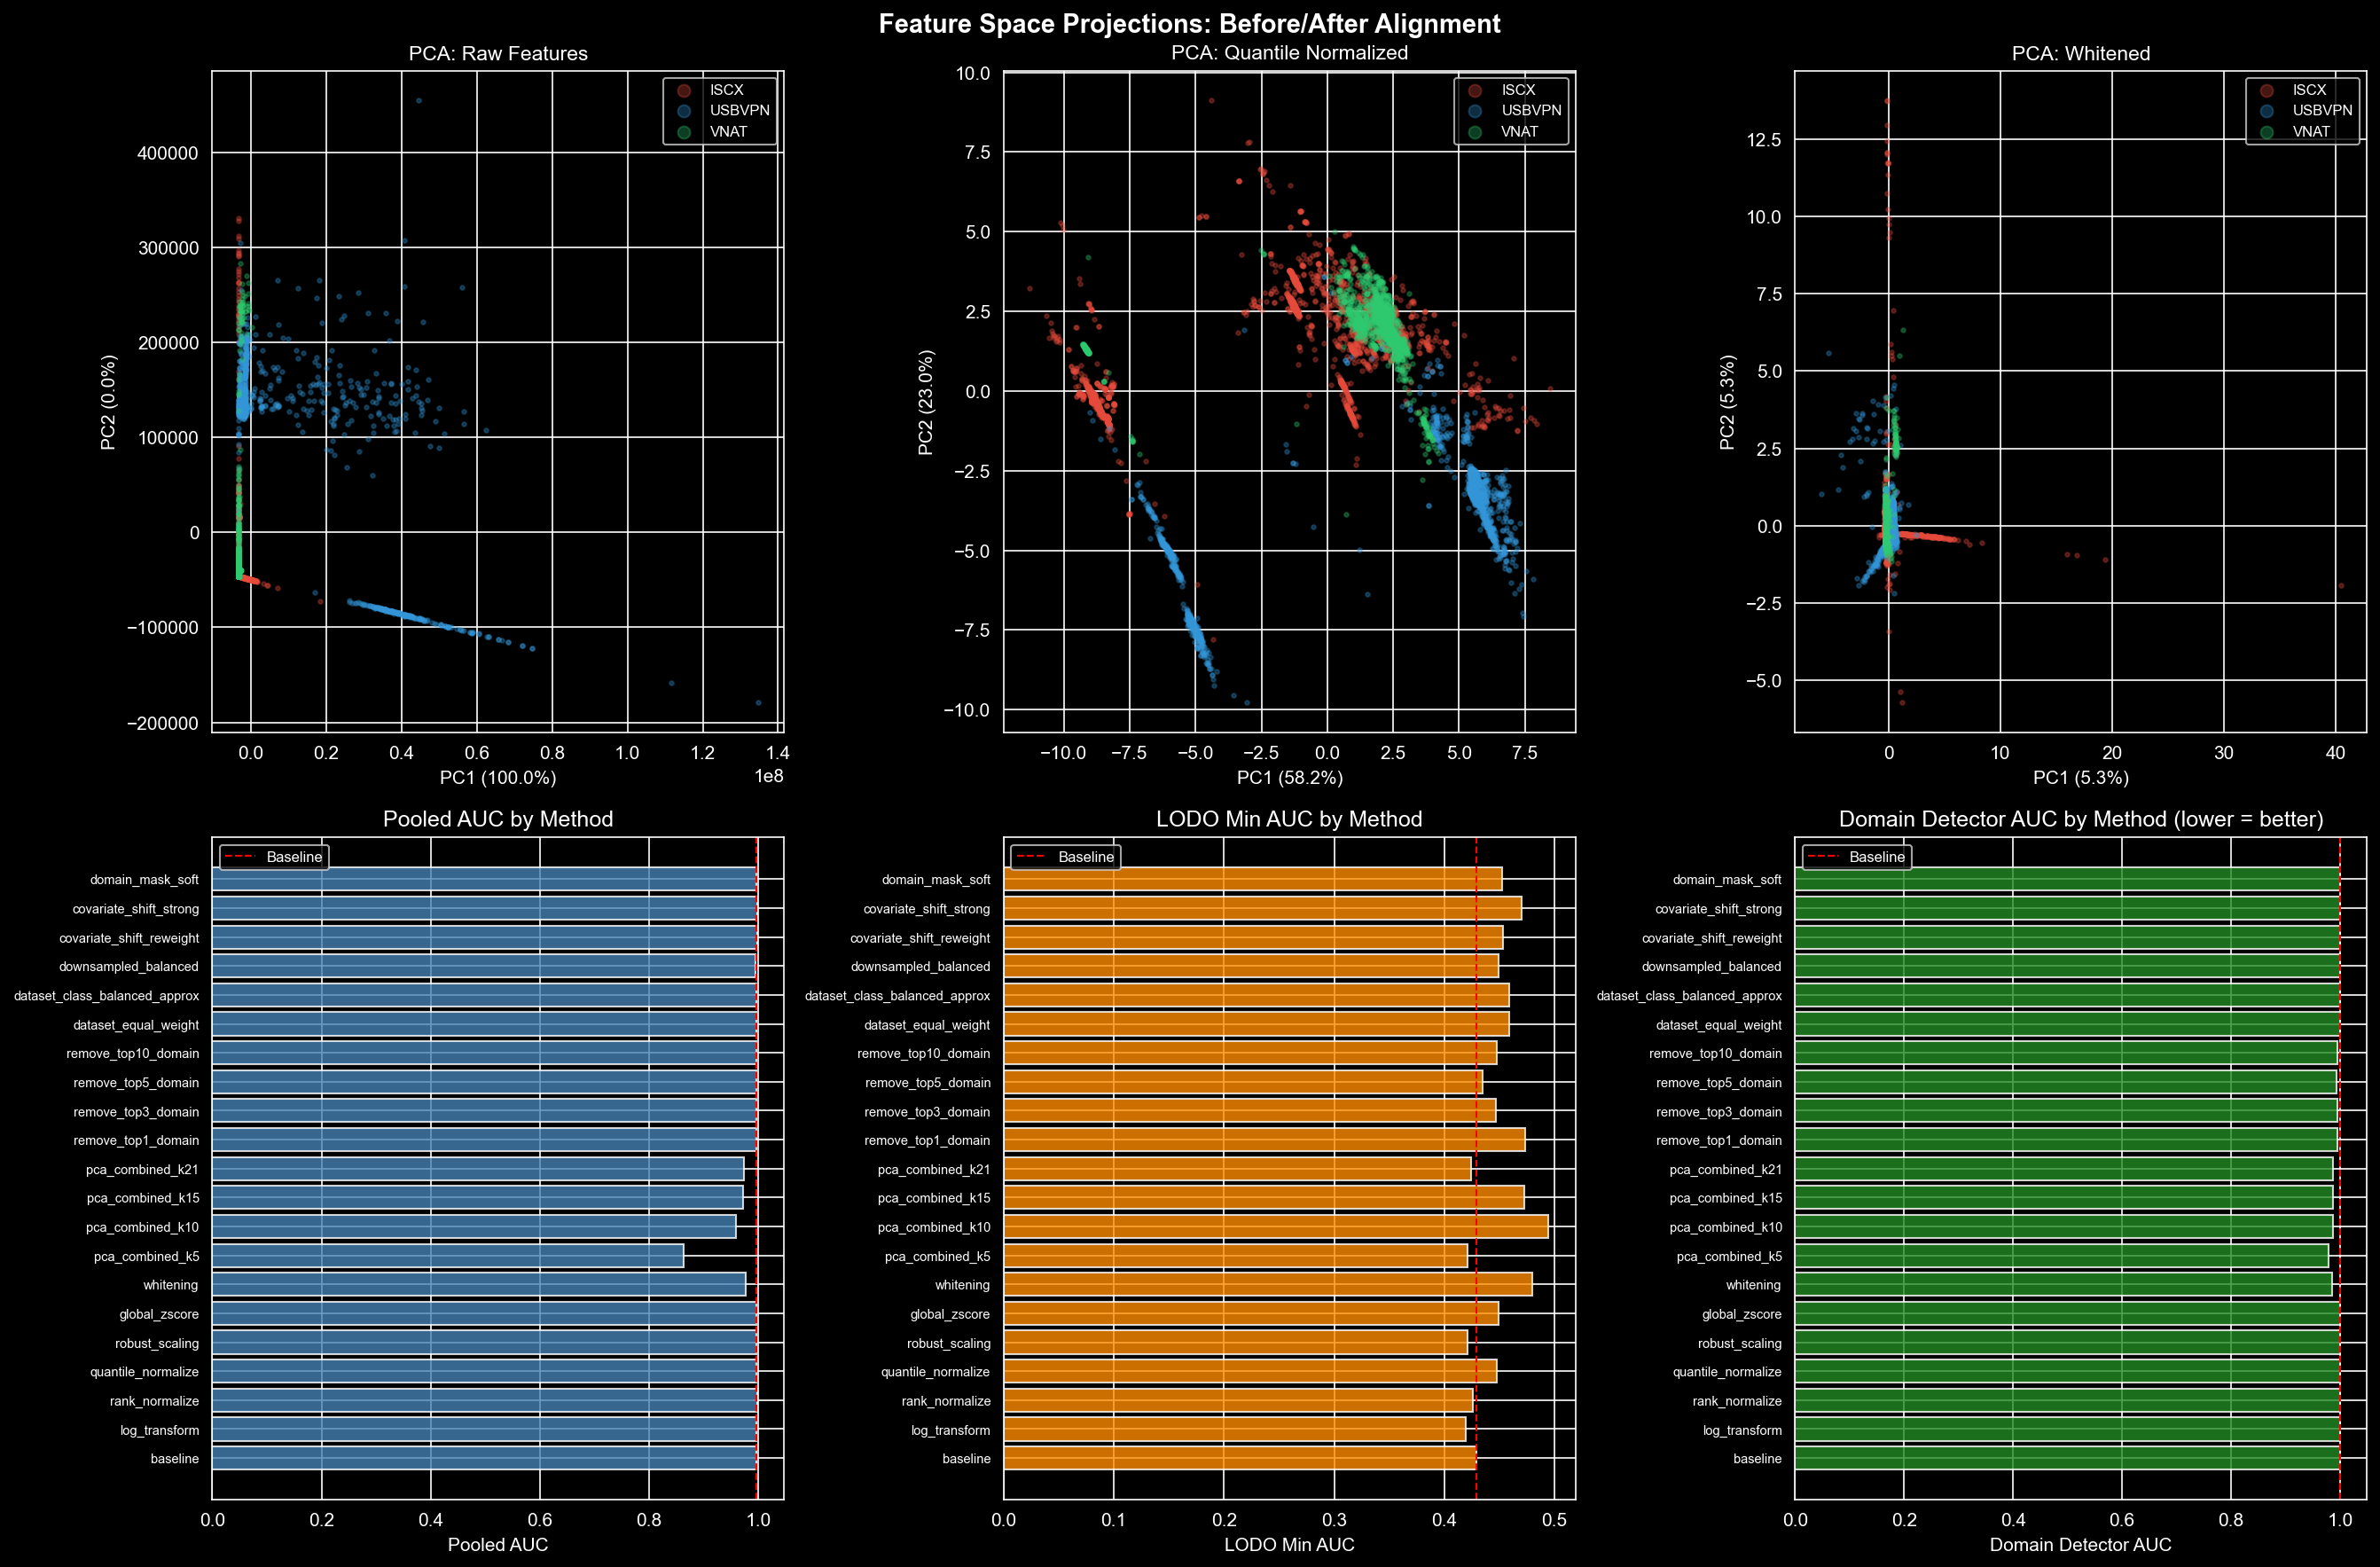


---
# 📋 Result Tables


### Alignment Method Summary

,method,pooled_auc,pooled_recall,pooled_fpr,worst_recall,worst_fpr,domain_det_auc,lodo_min_auc,lodo_mean_auc,degenerate,pooled_auc_delta,lodo_min_auc_delta,worst_recall_delta,worst_fpr_delta,domain_det_auc_delta,deployment_impact
0,baseline,0.9970,0.9898,0.0315,0.9678,0.2778,0.9993,0.4291,0.5327,False,0.0000,0.0000,0.0000,0.0000,0.0000,NEUTRAL (no meaningful change)
1,log_transform,0.9971,0.9893,0.0280,0.9635,0.2500,0.9993,0.4197,0.5301,False,0.0001,-0.0094,-0.0043,0.0278,0.0000,NEUTRAL (no meaningful change)
2,rank_normalize,0.9975,0.9932,0.0274,0.9807,0.3611,0.9993,0.4259,0.5375,False,0.0005,-0.0032,0.0129,-0.0833,0.0000,NEUTRAL (no meaningful change)
3,quantile_normalize,0.9968,0.9879,0.0277,0.9592,0.3333,0.9993,0.4480,0.5415,False,-0.0002,0.0189,-0.0086,-0.0555,0.0000,NEUTRAL (no meaningful change)
4,robust_scaling,0.9970,0.9869,0.0274,0.9571,0.2778,0.9993,0.4214,0.5390,False,0.0000,-0.0077,-0.0107,0.0000,0.0000,NEUTRAL (no meaningful change)
5,global_zscore,0.9967,0.9879,0.0302,0.9592,0.2778,0.9994,0.4489,0.5344,False,-0.0003,0.0198,-0.0086,0.0000,-0.0001,NEUTRAL (no meaningful change)
6,whitening,0.9769,0.8700,0.0248,0.5300,0.2222,0.9850,0.4795,0.6214,False,-0.0201,0.0504,-0.4378,0.0556,0.0143,HARMFUL (pooled degradation)
7,pca_combined_k5,0.8637,0.8748,0.4045,0.8283,0.4108,0.9787,0.4214,0.6158,False,-0.1333,-0.0077,-0.1395,-0.1330,0.0206,HARMFUL (pooled degradation)
8,pca_combined_k10,0.9594,0.9175,0.1588,0.6760,0.3056,0.9866,0.4945,0.6590,False,-0.0376,0.0654,-0.2918,-0.0278,0.0127,HARMFUL (pooled degradation)
9,pca_combined_k15,0.9713,0.7846,0.0076,0.4034,0.0133,0.9877,0.4730,0.6392,False,-0.0257,0.0439,-0.5644,0.2645,0.0116,HARMFUL (pooled degradation)


### Covariate Shift Results

,method,pooled_auc,pooled_recall,pooled_fpr,worst_recall,worst_fpr,domain_det_auc,lodo_min_auc,lodo_mean_auc
0,covariate_shift_reweight,0.9974,0.9927,0.0146,0.9764,0.3056,0.9993,0.4534,0.5396
1,covariate_shift_strong,0.9974,0.9932,0.0181,0.9764,0.3889,0.9993,0.4705,0.5592


...

### Pca Alignment Results

,method,pooled_auc,pooled_recall,pooled_fpr,worst_recall,worst_fpr,domain_det_auc,lodo_min_auc,lodo_mean_auc
0,pca_combined_k5,0.8637,0.8748,0.4045,0.8283,0.4108,0.9787,0.4214,0.6158
1,pca_combined_k10,0.9594,0.9175,0.1588,0.6760,0.3056,0.9866,0.4945,0.6590
2,pca_combined_k15,0.9713,0.7846,0.0076,0.4034,0.0133,0.9877,0.4730,0.6392
3,pca_combined_k21,0.9729,0.9267,0.1353,0.7425,0.4444,0.9875,0.4246,0.6318



---
### 🏁 Alignment Verdict

```json
{
  "verdict": "LIMITED_TRANSFER_GAIN",
  "verdict_text": "Statistically detectable but operationally insufficient transfer gains observed. Some methods show modest LODO improvements, but the best achievable LODO AUC remains near random-chance level, making the improvement unsuitable for deployment. The fundamental domain shift remains dominant.",
  "baseline_lodo_min": 0.4291,
  "best_lodo_min": 0.4945,
  "best_lodo_method": "pca_combined_k10",
  "lodo_improvement": 0.0654,
  "baseline_domain_det": 0.9993,
  "best_domain_det": 0.9787,
  "best_domain_method": "pca_combined_k5",
  "domain_reduction": 0.0206,
  "n_methods_tested": 21,
  "n_methods_helped": 14,
  "n_methods_failed": 0
}
```


✅ NB43 gallery complete.


In [13]:
# ── Results Gallery: NB43 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_finalization" / "domain_shift_alignment"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB43 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {_p.stem.replace("_", " ").title()}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {_c.stem.replace("_", " ").title()}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {_j.stem.replace("_", " ").title()}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB43 gallery complete.')
